In [2]:
import pandas as pd
import numpy as np

ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print(ratings.head())
print(ratings.shape)

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
(100000, 4)


In [3]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings,
    test_size=0.2, #Im gonna split 20% for test
    random_state=42
)

print(train.shape)
print(test.shape)

(80000, 4)
(20000, 4)


# Memory Based CF

User-item matrix

In [4]:
R = train.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print(R.shape)
print(R.head())

(943, 1653)
movie_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                               ...   
1          NaN   3.0   4.0   NaN   3.0   NaN   4.0   NaN   5.0   3.0  ...   
2          4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5          4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

movie_id  1668  1670  1671  1672  1673  1676  1678  1679  1680  1681  
user_id                                                               
1          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
5          NaN   NaN  

The dataset is very sparse, i.e. it has lot of NaN values and we're taking user similarity where both users have rated that movie

In [5]:
#use nested for loop to filter out ratings which both users have given
from sklearn.metrics.pairwise import cosine_similarity

R_filled = R.fillna(0)

similarity = cosine_similarity(R_filled)

similarity = pd.DataFrame(
    similarity,
    index=R.index,
    columns=R.index
 )

print(similarity.head()) #gives sim(i, j)

user_id       1         2         3         4         5         6         7    \
user_id                                                                         
1        1.000000  0.136196  0.030424  0.026203  0.284613  0.331412  0.319056   
2        0.136196  1.000000  0.114644  0.168220  0.093128  0.162165  0.095848   
3        0.030424  0.114644  1.000000  0.346894  0.000000  0.085071  0.032829   
4        0.026203  0.168220  0.346894  1.000000  0.011848  0.051287  0.075209   
5        0.284613  0.093128  0.000000  0.011848  1.000000  0.168527  0.298438   

user_id       8         9         10   ...       934       935       936  \
user_id                                ...                                 
1        0.274139  0.083486  0.281396  ...  0.277459  0.084849  0.205849   
2        0.091360  0.149476  0.125701  ...  0.149359  0.268977  0.320095   
3        0.053875  0.060177  0.052552  ...  0.021713  0.017707  0.154299   
4        0.142100  0.060465  0.035202  ...  0.034908

We will be using KNN to predict output as rating by user depends on similarity of K Nearest Similar Neighbours

In [6]:
def predict(user, movie, K=20): #picking top k similar users
    if movie not in R.columns:
        return train["rating"].mean()
    
    sims = similarity.loc[user].drop(user)

    sims = sims[sims>0]

    sims = sims[R.loc[sims.index, movie].notna()]
    sims = sims.sort_values(ascending=False).head(K)

    if (len(sims) == 0):
        return train["rating"].mean()

    ratings = R.loc[sims.index, movie] #neighbor ratings

    return np.clip(
        np.sum(sims.values * ratings.values) / np.sum(sims.values),
        1 , 5 
    ) #np.clip() forces predictions to stay between 1 and 5

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for K in [5, 10, 20, 50]:

    predictions = [
        predict(row["user_id"], row["movie_id"], K)
        for _, row in test.iterrows()
    ]

    mae = mean_absolute_error(test["rating"], predictions)
    rmse = np.sqrt(mean_squared_error(test["rating"], predictions))

    results.append([K, mae, rmse])

results

[[5, 0.8420341264596369, np.float64(1.061974765932667)],
 [10, 0.8151493886313372, np.float64(1.0261999232718149)],
 [20, 0.8028164351910148, np.float64(1.011828294689408)],
 [50, 0.8010231653254491, np.float64(1.0098399681374197)]]

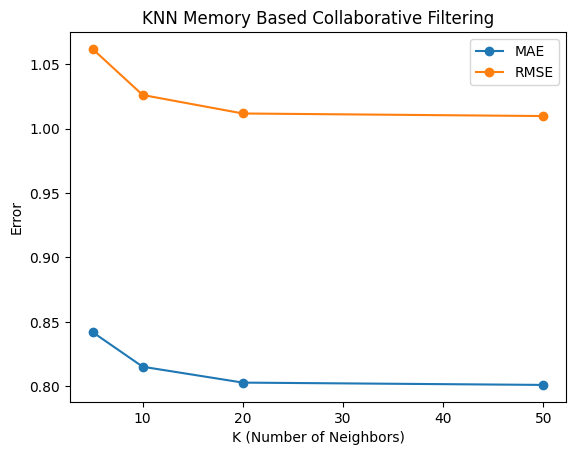

In [46]:
import matplotlib.pyplot as plt

knn_results_df = pd.DataFrame(
    results,
    columns=["K", "MAE", "RMSE"]
)

plt.plot(knn_results_df["K"], knn_results_df["MAE"], marker='o', label="MAE")
plt.plot(knn_results_df["K"], knn_results_df["RMSE"], marker='o', label="RMSE")

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Error")
plt.title("KNN Memory Based Collaborative Filtering")
plt.legend()
plt.show()

The error converges to lower value for higher values of K

# Model Based CF
Matrix Factorisation

In [28]:
users = train["user_id"].unique()
movies = train["movie_id"].unique()

user_to_idx = {u : i for i, u in enumerate(users)}
movie_to_idx = {m : i for i, m in enumerate(movies)}
#convert to indices to access in matrix             

In Model Based CF we represent users and movies in terms of latent vectors based on k hidden features 

**Loss Function**
$$
L = \frac{1}{2}(r_{\text{actual}} - r_{\text{predicted}})^2
$$
$$
L = \frac{1}{2}(r_{\text{actual}} - P_u^TQ_i)^2
$$

**Slope**
$$
\frac{\partial L}{\partial P_u}
=
-(r_{\text{actual}} - P_u^TQ_i)Q_i
$$
$$
\frac{\partial L}{\partial Q_i}
=
-(r_{\text{actual}} - P_u^TQ_i)P_u
$$

In [ ]:
learning_rates = [0.001, 0.005, 0.01]
epochs_list = [10, 20, 30]
reg_values = [0, 0.02]

results = []

for lr in learning_rates:
    for epochs in epochs_list:
        for reg in reg_values:

            # Start every experiment from the same initial factors
            P = P_normal.copy()
            Q = Q_normal.copy()

            for epoch in range(epochs):

                for _, row in train.iterrows():

                    u = user_to_idx[row["user_id"]]
                    i = movie_to_idx[row["movie_id"]]
                    r = row["rating"]

                    pred = np.dot(P[u], Q[i])
                    error = r - pred

                    P[u] += lr * (error * Q[i] - reg * P[u])
                    Q[i] += lr * (error * P[u] - reg * Q[i])

            # Test predictions
            predictions = []

            for _, row in test.iterrows():

                user = row["user_id"]
                movie = row["movie_id"]

                if user in user_to_idx and movie in movie_to_idx:
                    u = user_to_idx[user]
                    i = movie_to_idx[movie]

                    pred = np.dot(P[u], Q[i])
                    pred = np.clip(pred, 1, 5)
                else:
                    pred = train["rating"].mean()

                predictions.append(pred)

            mae = mean_absolute_error(test["rating"], predictions)
            rmse = np.sqrt(mean_squared_error(test["rating"], predictions))

            results.append([lr, epochs, reg, mae, rmse])

In [42]:
predictions = []

global_mean = train["rating"].mean()

# Testing Loop
for _, row in test.iterrows():

    user = row["user_id"]
    movie = row["movie_id"]

    if user in user_to_idx and movie in movie_to_idx:
        u = user_to_idx[user]
        i = movie_to_idx[movie]

        pred = np.dot(P[u], Q[i])
        pred = np.clip(pred, 1, 5)

    else:
        pred = global_mean

    predictions.append(pred)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test["rating"], predictions)
rmse = np.sqrt(mean_squared_error(test["rating"], predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.7510340847162262
RMSE: 0.958369197859577


Now lets add Ridge Regularization in order to prevent overfitting

**Loss Function with L2 Regularization**

$$
L =
\frac{1}{2}(r_{\text{actual}} - P_u^TQ_i)^2
+
\frac{\lambda}{2}
\left(
\|P_u\|^2 + \|Q_i\|^2
\right)
$$

The second term is the penalty term

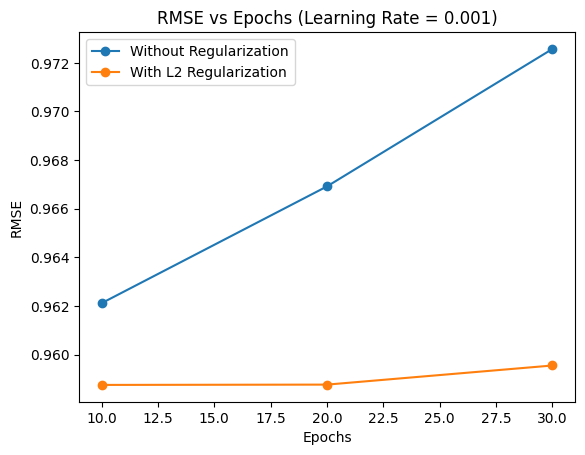

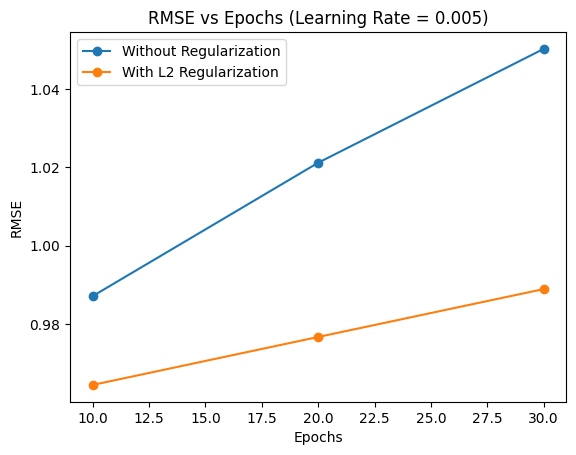

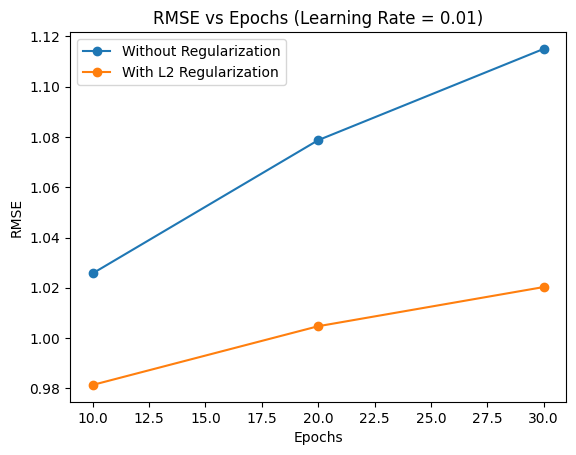

In [47]:
import matplotlib.pyplot as plt

for lr in learning_rates:
    subset = results_df[results_df["Learning Rate"] == lr]

    for reg in reg_values:
        data = subset[subset["Regularization"] == reg]

        label = "Without Regularization" if reg == 0 else "With L2 Regularization"

        plt.plot(
            data["Epochs"],
            data["RMSE"],
            marker="o",
            label=label
        )

    plt.title(f"RMSE vs Epochs (Learning Rate = {lr})")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()

As we can see, model performs much better with regularization than without

Comparing best results of Model Based CF with Memory Based CF :


In [49]:
best_model_based = results_df.loc[
    results_df["RMSE"].idxmin()
]

best_knn = knn_results_df.loc[
    knn_results_df["RMSE"].idxmin()
]

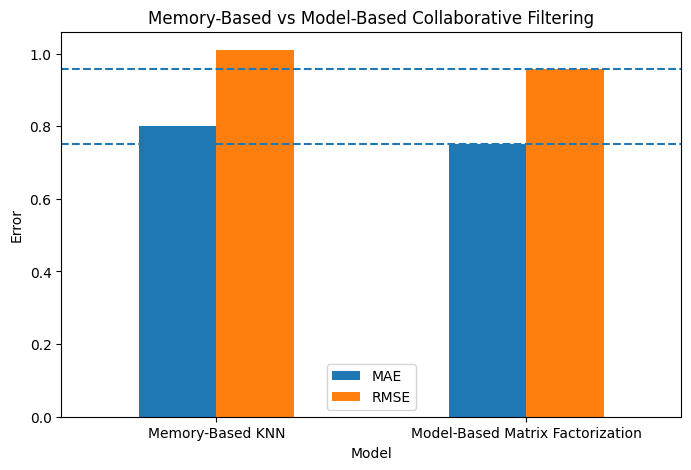

In [52]:
ax = comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(8, 5)
)

# Minimum MAE and RMSE
min_mae = comparison["MAE"].min()
min_rmse = comparison["RMSE"].min()

# Horizontal dashed lines
ax.axhline(min_mae, linestyle="--")
ax.axhline(min_rmse, linestyle="--")

ax.set_title("Memory-Based vs Model-Based Collaborative Filtering")
ax.set_ylabel("Error")
ax.set_xticklabels(comparison["Model"], rotation=0)
ax.legend()

plt.show()

Clearly shows that Model Based performs better than Memory Based as in Model Based we split data into hidden features and use gradient descent to come close to the actual rating instead of depending on other users or items and their reviews